<a href="https://colab.research.google.com/github/jessiepsx/Machine-Learning-Practitioner/blob/main/Sistema_de_Recomendacao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics.pairwise import euclidean_distances

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train = np.expand_dims(x_train, axis=-1) / 255.0

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
global_avg_layer = tf.keras.layers.GlobalAveragePooling2D()
model = Model(inputs=base_model.input, outputs=global_avg_layer(base_model.output))

def preprocess_images(images):
    images_resized = tf.image.resize(images, (32, 32))
    images_rgb = tf.image.grayscale_to_rgb(images_resized)
    return images_rgb.numpy()

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 47ms/step
Buscando similaridade para a classe com label 3 (Vestido) no índice 3


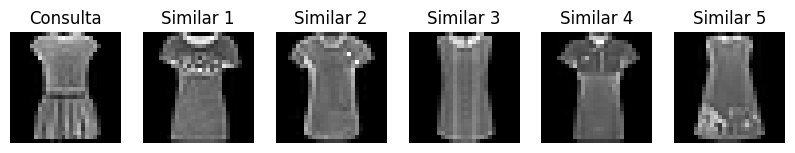

In [22]:
x_train_processed = preprocess_images(x_train)
embeddings = model.predict(x_train_processed)

def find_similar_images(query_idx, top_n=5):
    query_embedding = embeddings[query_idx].reshape(1, -1)
    distances = euclidean_distances(query_embedding, embeddings).flatten()
    similar_idxs = np.argsort(distances)[1:top_n+1]

    plt.figure(figsize=(10, 2))
    plt.subplot(1, top_n+1, 1)
    plt.imshow(x_train[query_idx].squeeze(), cmap='gray')
    plt.title("Consulta")
    plt.axis("off")

    for i, idx in enumerate(similar_idxs):
        plt.subplot(1, top_n+1, i+2)
        plt.imshow(x_train[idx].squeeze(), cmap='gray')
        plt.title(f"Similar {i+1}")
        plt.axis("off")
    plt.show()

#aqui define o label da categoria
LABEL_VESTIDO = 3

indices_bolsas = np.where(y_train.flatten() == LABEL_VESTIDO)[0]

if len(indices_bolsas) > 0:
    indice_de_consulta = indices_bolsas[0]
    print(f"Buscando similaridade para a classe com label {LABEL_VESTIDO} (Vestido) no índice {indice_de_consulta}")
    find_similar_images(indice_de_consulta)

else:
    print(f"Aviso: Não foi encontrado nenhum item com o label {LABEL_VESTIDO} no conjunto de treino.")


In [ ]:

#CATEGORIAS / LABEL
#0,T-shirt/top (Camiseta),
#1,Trouser (Calça),
#2,Pullover,
#3,Dress (Vestido),
#4,Coat (Casaco),
#5,Sandal (Sandália),
#6,Shirt (Camisa),
#7,Sneaker (Tênis),
#8,Bag (Bolsa),
#9,Ankle boot (Bota)

